## <font color = 'blue'>Introduction:</font> What is in this notebook?

This notebook contains code relevant to PunctaFinder users who want to create a validated dataset, determine the optimal threshold values for punctum detection based on such a dataset and visualise the results of the threshold value optimisation.

**The notebook contains the following sections:**

**Section 0:** Loading relevant Python modules + other code

**Section 1:** Validated dataset creation

**Section 2:** Threshold value optimisation (with bootstrapping)

**Section 3:** Visualising the outcomes


## <font color = 'blue'>Section 0:</font> Loading relevant Python modules + other code
- Import relevant Python modules;
- 3 custom colour maps for punctum visualsation, where NaN-values will be transparent;
- define 2 PunctaFinder functions (1 for creating validated dataset, 1 for detecting puncta).

In [12]:
# used in PunctaFinder
import pandas as pd
import numpy as np
import math
import copy

import skimage
from skimage import io
from skimage import segmentation
from skimage import filters

# used for bootstrapping in threshold optimisation
import random

# used for visualisation of PF outputs and obtained threshold values
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import matplotlib.patches as patch
from matplotlib.patches import Rectangle
import matplotlib.patheffects as patheffects
%matplotlib inline

In [2]:
### Colour maps for punctum visualisation (overlay with the microscopy image) 
# (NaN values will be transparent)
red_ = copy.copy(plt.cm.get_cmap('bwr_r')) # copy of the original cmap
red_.set_bad(alpha=0) # 'bad' values will be transparent

green_ = copy.copy(plt.cm.get_cmap('brg_r'))
green_.set_bad(alpha = 0)

blue_ = copy.copy(plt.cm.get_cmap('bwr')) # copy of the original cmap
blue_.set_bad(alpha=0) # 'bad' values will be transparent


In [3]:
def PF_validated_data(fluor_image, cell_mask, punctum_diameter, overlap, N_cat1, N_cat2, N_cat3):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):       
        return False, False, False, False, print("cell too close to FOV edge")
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            return False, False, False, False, print("cell too close to FOV edge")
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: assess all punctum candidates
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner

            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter+4, punctum_diameter+4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)

                    if ratio_fluor_local > 1 and ratio_fluor_overall > 1: 
                        ## save information pertaining to this location
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["diameter"] = punctum_diameter
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]

                        # dataframe with all candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### PART 2b: remove candidate puncta that are too close together/overlap too much    
            ## Goal: remove locations that overlap more than you allow; keep the brightest candidate punctum 
            
            # first, sort the data frame from brightest to dimmest candidate (sort by fluorescence intensity ratio punctum/cell)
            df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
            
            # clean up the indices on the data frame with all potential puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis = 1)
    
            # compare each potential punctum against all puncta above it in the data frame
            initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
            for i1 in initial_label:
                current_row = df_puncta.loc[i1]
                label_list = list(df_puncta.index) # all id's currently present in the table
                current_index = label_list.index(i1) # index of current row's id, to know how many candidates to compare against (candidates that are above it in the table)
                for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                    prev_label = label_list[i2]
                    prev_row = df_puncta.loc[prev_label]
                    # extract relevant information about the 2 candidate puncta
                    current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                    current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                    max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                    current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                    # check for overlap between candidate puncta
                    if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                        continue # start next iteration of the loop
                        
                    elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                        continue # start next iteration of the loop
                        
                    else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                        # selection of the characteristic that will be combined to decide which candidate is best
                        current = current_overall; prev = prev_overall
                        # actual comparison between candidates (+ removal of the worst one)
                        if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                            df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                            break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                        else: # the other candidate is the one that should be removed
                            df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
            
            ## clean up indices of df_puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis=1)
            
            #### PART 3: assign an identity to each remaining location (category 1/2/3 or nonpunctate)
            ## approach: all locations are sorted from brightest to dimmest (high to low average fluorescence intensity)
            ## the N_cat1 best locations are labeled as category 1 puncta, the next N_cat2 locations are labeled as category 2 puncta, the next N_cat3 are labelled as category 3 puncta and all others are nonpunctate
            ## N_cat1, N_cat2 and N_cat3 are all based on visual inspection
            
            # make list with the "state" of each location in the dataframe
            state_list = N_cat1*["category 1"] + N_cat2*["category 2"] + N_cat3*["category 3"] + (len(df_puncta)-N_cat1-N_cat2-N_cat3)*["nonpunctate"]
            # add this list to the dataframe
            df_puncta["state"] = state_list
                        
            #### PART 4: create masks that show the puncta belonging to each category 
                
            height = len(masked); width = len(masked[0])
            mask_puncta1 = np.empty((height, width, )); mask_puncta1[:] = np.nan 
            mask_puncta2 = np.empty((height, width, )); mask_puncta2[:] = np.nan
            mask_puncta3 = np.empty((height, width, )); mask_puncta3[:] = np.nan
            
            ## first create the mask for the puncta of category 1
            df_cat1 = df_puncta[df_puncta["state"] == "category 1"]
            x_coordinates = list(df_cat1["x"]); y_coordinates = list(df_cat1["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta1[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
            
            ## repeat approach for puncta of category 2
            df_cat2 = df_puncta[df_puncta["state"] == "category 2"]
            x_coordinates = list(df_cat2["x"]); y_coordinates = list(df_cat2["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta2[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
                
            ## repeat approach for puncta of category 3
            df_cat3 = df_puncta[df_puncta["state"] == "category 3"]
            x_coordinates = list(df_cat3["x"]); y_coordinates = list(df_cat3["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta3[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
                
                
            #### PART 5: output = dataframe with identity of all locations, cropped image of masked cell, masks that show the puncta belonging to each of the 3 categories
            return df_puncta, masked, mask_puncta1, mask_puncta2, mask_puncta3

In [4]:
def PF_visualisation(fluor_image, cell_mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        # Add None to all columns of output data frame (show that analysis couldn't be performed)
        df_output["# puncta"] = [None]
        df_output["punctum sizes (px)"] = [None]
        df_output["punctum intensities"] = [None]
        df_output["average size (px)"] = [None]
        df_output["average intensity, puncta"] = [None]
        df_output["average intensity, cytoplasm"] = [None]
        df_output["average cell intensity"] = [av_fluor_cell]
        df_output["coordinates [x,y]"] = [None]
        df_output["punctum intensities, set size"] = [None]
        df_output["average punctum intensity, set size"] = [None]
        df_output["average cytoplasm intensity, set size"] = [None]
        
        return df_output, print("analysis not possible: cell too close to FOV edge"), None, None, None
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            # Add None to all columns of output data frame (show that analysis couldn't be performed)
            df_output["# puncta"] = [None]
            df_output["punctum sizes (px)"] = [None]
            df_output["punctum intensities"] = [None]
            df_output["average size (px)"] = [None]
            df_output["average intensity, puncta"] = [None]
            df_output["average intensity, cytoplasm"] = [None]
            df_output["average cell intensity"] = [av_fluor_cell]
            df_output["coordinates [x,y]"] = [None]
            df_output["punctum intensities, set size"] = [None]
            df_output["average punctum intensity, set size"] = [None]
            df_output["average cytoplasm intensity, set size"] = [None]
        
            return df_output, print("analysis not possible: cell too close to FOV edge"), None, None, None
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                df_output["# puncta"] = [0]; 
                df_output["average size (px)"] = [None]
                df_output["punctum sizes (px)"] = [None]
                df_output["punctum intensities"] = [None]
                df_output["average intensity, puncta"] = [None]
                df_output["average intensity, cytoplasm"] = [av_fluor_cell]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [None]
                df_output["punctum intensities, set size"] = [None]
                df_output["average punctum intensity, set size"] = [None]
                df_output["average cytoplasm intensity, set size"] = [av_fluor_cell]
            
                return df_output, masked, None, None, None
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than you want to allow
                ## keep the candidate that has best fluorescence intensity ratio; the brightest candidate 
                
                # sort the data frame from brightest to dimmest candidate; this improves detection of puncta that are close together
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                            continue # start next iteration of the loop
                        
                        elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                #### PART 3a: determine size of the puncta (which don't overlap too much)
                ## approach: take surrounding ROI in which each punctum was found and binarize it using multi-Otsu filter
                # also calculate the average intensity of each punctum (based on the set diameter)
                threshold_size = 3 # threshold to determine whether regular Otsu or multi-Otsu gives better result
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"])
                
                height = len(masked); width = len(masked[0])
                new_mask_puncta_variable_individual = np.zeros((height, width)) # map that will show only the puncta after binarisation, but with a different value for each individual punctum
                new_mask_puncta_set_size = np.zeros((height, width)) # map that will show only the puncta with set size
                
                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                intensity_variable_list = [] # list to store average intensities of puncta in the cell with variable punctum size (obtained through binarisation of ROI)
                size_variable_list = [] # list to store the size (in px) of each punctum
                coordinate_list = [] # list to store punctum coordinates
                
                for i1 in range(len(x_coordinates)):
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])
                    
                    punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    # remove 0 intensity px (punctum on cell edge) and calculate average intensity
                    punctum = punctum.flatten()
                    only_punctum = np.delete(punctum, np.where(punctum == 0))
                    intensity_set_list.append(np.mean(only_punctum))
                    # minimum size for punctum (smaller if punctum is on cell edge); use for condition after binarisation
                    if 0 in punctum: # punctum is on cell edge
                        punctum_min_size = d_floor**2
                    else: # punctum is not on cell edge
                        punctum_min_size = d_ceiling**2
                    
                    roi = masked[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    roi_ = roi.flatten()
                    roi_ = np.delete(roi_, np.where(roi_ == 0)) # remove all px outside cell mask (if punctum is near cell edge)
                    roi1 = roi_[:] # copy that can be changed (original roi_ stays intact)
                    
                    mask_punctum = np.full((len(roi), len(roi[0])), False); mask_punctum[d_ceiling +1, d_ceiling +1] = True # mock array to initiate the while loop (which keeps going until the mask is connects to midpoint)
                    threshold_i1 = 0 # # iterator to enable the first iteration of while loop to happen with initial threshold                    
                    threshold = filters.threshold_otsu(roi1)
                    while list(mask_punctum.flatten()).count(True) == 1:
                        if threshold_i1 != 0: # loop has been performed at least once, remove brightest px from roi, get new threshold
                            roi1 = np.delete(roi1, np.where(roi1 > threshold))
                            threshold = filters.threshold_otsu(roi1) # determines the threshold value (to separate punctum from background)
                    
                        # apply (current) threshold value and get punctum mask
                        roi_binary = roi > threshold # True: px is part of punctum, False: px is part of surrounding
                        roi_binary[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                        mask_punctum = segmentation.flood(roi_binary, (d_ceiling +1, d_ceiling +1), connectivity = 1) # mask that contains all px directly connected (diagonals not allowed) to the midpoint px 
                        # punctum mask as a 0/1 array
                        punctum_binarized = np.zeros((len(roi), len(roi[0])))
                        punctum_binarized[mask_punctum] = 1 # 0/1 array with 1 at positions that are part of the punctum
                    
                        threshold_i1 += 1
                        
                    # get px that are part of the punctum and their mean intensity (once a satisfying punctum has been obtained)
                    punctum_only = (roi * punctum_binarized).flatten() # has 0 outside of punctum
                    punctum_px = np.delete(punctum_only, np.where(punctum_only == 0))
                    
                    # perform more stringent binarisation
                    roi2 = roi1[:] # a copy of the roi1; brightest px removed if required for first punctum (original stays intact)
                    
                    if len(set(roi2)) >= 4: # only perform multi-Otsu thresholding if roi is varied enough to accomodate it
                        threshold2 = filters.threshold_multiotsu(roi2, 3)[-1]
                        if threshold2 <= threshold: # the Otsu split 3-way threshold is not more stringent than "regular" Otsu; apply Otsu-thresholding on ONLY the punctum
                            threshold2 = filters.threshold_otsu(punctum_px)
                    else: # cannot perform multi-Otsu thresholding; set threshold2 equal to initial threshold, output will be initial punctum
                        threshold2 = threshold
                    
                    # apply threshold2 to ROI and get mask for punctum
                    roi_binary2 = roi > threshold2
                    roi_binary2[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                    mask_punctum2 = segmentation.flood(roi_binary2, (d_ceiling +1, d_ceiling +1), connectivity = 1)
                        
                    # punctum mask as a 0/1 array 
                    punctum_binarized2 = np.zeros((len(roi), len(roi[0])))
                    punctum_binarized2[mask_punctum2] = 1
                    
                    # choose between the more lenient threshold and the more stringent threshold                   
                    mid_px = [px for px in punctum_px if px <= threshold2] # px from punctum1 that are not part of punctum2
                    punctum2_px = [px for px in punctum_px if px > threshold2]
                    bg_px = [px for px in roi_ if px <= threshold]
                    if len(mid_px) > 0 and list(punctum_binarized2.flatten()).count(1) >= punctum_min_size: # more stringently binarisation makes a different and punctum will only be considered if it is sufficiently big 
                        delta_mid = max(mid_px)-min(mid_px)
                        if delta_mid == 0 and len(punctum2_px) > 0:
                            delta_mid = min(punctum2_px) - max(mid_px) # prevent "error" caused by /0
                        elif delta_mid == 0:
                            delta_mid = max(mid_px)-max(bg_px)
                        
                        peak_roi = len(roi1)/((max(roi1)-min(roi1)))
                        peak_mid = len(mid_px)/delta_mid
                        # alternative peak_mid (exclude brightest px; sometimes it makes delta fl unnecessarily large)
                        if len(mid_px) > 2: # if mid region is very small, calculating alternative doesn't make sense
                            alt_mid = sorted(mid_px)[:-1]
                            delta_alt = alt_mid[-1]-alt_mid[0]
                            if delta_alt == 0:
                                delta_alt = delta_mid
                            alt_peak_mid = len(alt_mid)/delta_alt
                            # choose to use alternative value if it improves enough compared to original (always at least 1.5x better, but more for brighter spots)
                            if alt_peak_mid/peak_mid >= max([np.mean(mid_px)/50, 1.5]):
                                peak_mid = alt_peak_mid
                        
                        
                        if len(punctum2_px) > 1: # at least 2 px present in most stringently binarised punctum
                            delta_punctum2 = max(punctum2_px)-min(punctum2_px)
                            if delta_punctum2 == 0:
                                delta_punctum2 = max(punctum2_px)-max(mid_px)
                        else: # punctum2 is equal to punctum1
                            delta_punctum2 = max(punctum_px) - min(punctum_px)
                        peak_punctum1 = len(punctum_px)/(max(punctum_px)-min(punctum_px))
                        peak_punctum2 = len(punctum2_px)/delta_punctum2
                        
                        if peak_mid/peak_roi >= 2: # there is a clear, darker subpopulation within punctum1
                            punctum_binarized_ = punctum_binarized2
                        elif peak_mid/peak_roi >= 1: # there may be a subpopulation within punctum1 (based on peak_mid) and punctum1 is more "peaky" than punctum2
                            if peak_punctum1/peak_roi >= 1: 
                                punctum_binarized_ = punctum_binarized2
                            elif peak_punctum1/peak_roi >= 0.4 and peak_punctum1 > peak_punctum2:
                                punctum_binarized_ = punctum_binarized2
                            else:
                                punctum_binarized_ = punctum_binarized
                        else: # punctum1 is better fit than punctum2
                            punctum_binarized_ = punctum_binarized
                            
                    else: # punctum2 was too small, keep punctum1
                        punctum_binarized_ = punctum_binarized
                        
                    # map punctum back to location within whole cell
                    # if it overlaps with a previously binarised (brighter) punctum, the shared px stay part of the other punctum (but midpoint is always part of this punctum)
                    roi_from_map = new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    punctum_binarized_ = np.where(roi_from_map != 0, 0, punctum_binarized_)# change 1 to 0 in new punctum mask if a previous punctum is already present
                    if list(punctum_binarized_.flatten()).count(1) == 0: # full overlap between current punctum and a previous one
                        punctum_binarized_[d_ceiling +1, d_ceiling +1] = 1 # midpoint is always part of punctum (even if it overlaps with binarisation of a brighter punctum)
                        roi_from_map[d_ceiling +1, d_ceiling +1] = 0 # place 0 at midpoint in the roi with previous puncta mapped in (so that addition in next step yields unique value)
                    # get current punctum on map
                    new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2] = punctum_binarized_*(i1+1) + roi_from_map # show punctum (size/shape determined by binarisation) within the cell and relative to other puncta (i1 +1, since i1 = 0 for first punctum)
                    new_mask_puncta_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 # show the punctum (with set size) within the cell (+ relative to other puncta)
                
                    # get (and save) average fluorescence intensity for current punctum
                    size_variable_list.append(list(punctum_binarized_.flatten()).count(1))
                    roi_punctum_masked = (roi * punctum_binarized_).flatten()
                    roi_punctum_masked = np.delete(roi_punctum_masked, np.where(roi_punctum_masked == 0))
                    intensity_variable_list.append(np.mean(roi_punctum_masked))
                
                # get binary version of puncta_variable_individual: 1 = part of any punctum; 0 = cytoplasm (and outside mask)
                new_mask_puncta_variable = np.where(new_mask_puncta_variable_individual > 1, 1, new_mask_puncta_variable_individual)
                # convert the masks from 0/1 to NaN/1 for visualisation
                puncta_variable_vis = np.where(new_mask_puncta_variable == 0, np.nan, new_mask_puncta_variable)
                puncta_variable_individual_vis = np.where(new_mask_puncta_variable_individual == 0, np.nan, new_mask_puncta_variable_individual)
                puncta_set_size_vis = np.where(new_mask_puncta_set_size == 0, np.nan, new_mask_puncta_set_size)
                
                # PART 3b: extract information about punctum size and fluorescence intensity of puncta and cytoplasm (both for variable and set-value punctum size)
                ## for variable punctum size
                # get average size of the detected puncta
                puncta_px = list(new_mask_puncta_variable.flatten()).count(1) # number of px that are part of a punctum
                punctum_size_av = puncta_px/len(df_puncta) # average size (in px) of a punctum detected in this cell
                # get average intensity of all punctum px
                masked_puncta_variable = (masked * new_mask_puncta_variable).flatten()
                only_puncta_variable = np.delete(masked_puncta_variable, np.where(masked_puncta_variable == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_variable = np.mean(only_puncta_variable)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_variable = new_mask_puncta_variable == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_variable = (masked * mask_background_variable).flatten()
                only_cyt = np.delete(masked_background_variable, np.where(masked_background_variable == 0))
                av_int_cyt_variable = np.mean(only_cyt)
                
                ## for set punctum size
                masked_puncta_set_size = (masked * new_mask_puncta_set_size).flatten()
                only_puncta_set_size = np.delete(masked_puncta_set_size, np.where(masked_puncta_set_size == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_set_size = np.mean(only_puncta_set_size)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_set_size = new_mask_puncta_set_size == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_set_size = (masked * mask_background_set_size).flatten()
                only_cyt = np.delete(masked_background_set_size, np.where(masked_background_set_size == 0))
                av_int_cyt_set_size = np.mean(only_cyt)
                
                #### PART 4: create the output data frame
                df_output["# puncta"] = [len(df_puncta)]
                df_output["punctum sizes (px)"] = [size_variable_list]
                df_output["punctum intensities"] = [intensity_variable_list]
                df_output["average size (px)"] = [punctum_size_av]
                df_output["average intensity, puncta"] = [av_int_puncta_variable]
                df_output["average intensity, cytoplasm"] = [av_int_cyt_variable]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [coordinate_list]
                df_output["punctum intensities, set size"] = [intensity_set_list]
                df_output["average punctum intensity, set size"] = [av_int_puncta_set_size]
                df_output["average cytoplasm intensity, set size"] = [av_int_cyt_set_size]
                
                return df_output, masked, puncta_set_size_vis, puncta_variable_vis, puncta_variable_individual_vis

## <font color = 'blue'>Section 1:</font> Validated dataset creation

_Before starting,_ users should determine:
- punctum diameter in px
- overlap parameter (if and how much puncta can overlap with each other)

**step 1:** initiate an empty dataframe

In [ ]:
# data frame to store the information
df_validated = pd.DataFrame({})

**step 2a:** visually inspect a single cell

_Approach:_ 

- load fluorescence image and cell mask (array with same size as the microscopy image, indicating all px that belong to the cell of interest);
- run PunctaFinder to get a cropped image that shows only this cell;
- visualise this one cell.

_Note:_ punctum detection thresholds don't matter here, you only want to crop the image, not detect the puncta (yet).

In [ ]:
# import fluorescence microscopy images and cell masks
mask = io.imread("G:/PATH_TO_IMAGE_FILE/masks.tif")
fluor = io.imread("G:/PATH_TO_IMAGE_FILE/image.tif")

In [ ]:
## run PF
df, cropped_cell, puncta_mask_set, puncta_mask_variable, puncta_mask_individual = PF_visualisation(fluor, mask, 3, 0, 10, 10, 0)
# input parameters are: fluorescence microscopy image, cell mask, punctum diameter, overlap parameter, threshold local instensity ratio, threshold global intensity ratio, threshold CV

## visualise
fig  = plt.figure(1,(5,5)); ax = plt.subplot(1,1,1)
ax.set_xticks([]); ax.set_yticks([])
ax.imshow(cropped_cell, cmap = 'Greys_r')


**step 2b:** determine the number of puncta present

The PunctaFinder can store information on 3 separate categories of puncta.

In this demo, we will make a distinction between:
- **category 1:** the brightest puncta (3 present in example cell 2); 
- **category 2:** dimmer but clear puncta (2 present in example cell 2);
- **category 3:** very dim puncta (1 present in example cell 2).

If you want to use **only 1 category**, simply provide a value of **0** for `N_cat2` and `N_cat3`

In [ ]:
N_cat1 = 3
N_cat2 = 2
N_cat3 = 1

**step 3:** run `PF_validated_data` (_i.e._ PunctaFinder function for dataset creation)with these numbers and visualise the outcome

_In this visualisation:_

- Puncta belonging to the 3 categories are shown in different colours: **<font color = 'green'>category 1</font>, <font color = 'red'>category 2</font>, <font color = 'blue'>category 3</font>**;
- The number written on each punctum corresponds to the row in the dataframe that describes this punctum; 
- The 5 brightest non-punctate locations (with the highest average fluorescence intensity) are indicated with a white rectangle and the index of their rows in the dataframe.

The written row numbers **(indices)** can be used to make manual changes in the dataframe with validated data (as demonstrated in **step 4**)

In [ ]:
# run PF for dataset creation
df, cropped_cell, mask_cat1, mask_cat2, mask_cat3 = PF_validated_data(fluor, mask, 3, 0, N_cat1, N_cat2, N_cat3)
# visualise the results
# initialise the figure and show the cropped cell
height = len(cropped_cell); width = len(cropped_cell[0])
fig = plt.figure(1,(width/height*2*5, 5))
ax1 = plt.subplot(1,2,1); ax1.set_xticks([]); ax1.set_yticks([])
ax2 = plt.subplot(1,2,2); ax2.set_xticks([]); ax2.set_yticks([])
ax1.imshow(cropped_cell, cmap = 'Greys_r'); ax2.imshow(cropped_cell, cmap = 'Greys_r')
# show the assigned puncta
ax2.set_title("assigned puncta", fontweight = 'bold', fontsize = 20)
ax2.imshow(mask_cat1, cmap = green_)
ax2.imshow(mask_cat2, cmap = red_)
ax2.imshow(mask_cat3, cmap = blue_)

# visualise the 3 brightest non_punctate spots
for i1 in np.arange(N_cat1+N_cat2+N_cat3, N_cat1+N_cat2+N_cat3+5, 1):
    loc = df_cell.iloc[i1]; x = loc["x"]; y = loc["y"]
    square = Rectangle((x-0.5*diameter, y-0.5*diameter), diameter, diameter, linewidth = 1.5, edgecolor = 'white', facecolor = 'none')
    ax2.add_patch(square)

# write indices on all assigned puncta and the 3 brightest non-punctate locations
for i1 in range(N_cat1+N_cat2+N_cat3+5):
    loc = df_cell.iloc[i1]; x = loc["x"]; y = loc["y"]
    ax2.text(x, y, str(i1), color = 'white', fontweight = 'bold', ha = 'center', va = 'center', fontsize = 15,
            path_effects=[patheffects.withStroke(linewidth=0.75, foreground='black')])
    
plt.tight_layout()

**step 4** _(optional)_**:** make manual changes to the dataframe

Use `df.at[index, "state"] = "desired state"` to make manual changes to the dataframe.

In [ ]:
df.at[2, "state"] = "nonpunctate"

**step 5:** add a unique identifier for this cell to the dataframe.

This identifier is an integer number; the column will be named `cellID`.

This information will be used for bootstrapping in the threshold value optimisation (splitting the total dataset into a training set and a test set).

In [ ]:
if len(df_validated) == 0:
    identifier = 1
else:
    identifiers_used = list(set(list(df_validated["cellID"])))
    identifier = max(identifiers_used) +1
    
df["cellID"] = len(df)*[identifier]

**step 6:** (optional) additional information (more columns) can be added to the dataframe;

use _e.g._ `df["replicate"] = len(df)*["replicateA"]` to add an identifier for the replicate

In [ ]:
df["replicate"] = len(df)*["replicateA"]

**step 7:** add validated data pertaining to 1 cell (`df`) to dataframe with all data (`df_validated`)

In [ ]:
df_validated = pd.concat([df_validated, df])

**step 8:** (once dataset is complete) save the dataframe as a .csv file

In [ ]:
df_validated.to_csv("G:/PATH_TO_LOCATION/validated_dataset_FILENAME.csv")

## <font color = 'blue'>Section 2:</font> Threshold value optimisation
(with bootstrapping)

_Approach:_ 

- Split data set 66%/33% into training and test set. Determine the optimal combination of threshold values based on the training set and apply the obtained thresholds to the test set; 
- Bootstrapping: repeat the whole approach for a **user-defined** number of iterations; 
- Visualise the obtained threshold values, difference in # puncta detected between manual detection and with PunctaFinder, and FP and FN occurrence rates for both training and test set for each bootstrap iteration; 
- For each of the three punctum detection criteria, determine the mean value across the bootstrap iterations so that this value can be used in all further data analysis. 

**step 1:** load the validated dataset

In [6]:
df_validated = pd.read_csv("G:/PATH_TO_LOCATION/validated_dataset_FILENAME.csv", header = 0, sep = ',')

**step 2:** user decisions for threhold optimisation:

- threshold values tested: for each of the three punctum selection criteria, the user sets a minimum value, maximum value and stepsize;
- weighting factor (`FN_weight`) for false negatives within the test statistic according to `test_statistic = #FPs + FN_weight * #FNs`;
- number of bootstrap iterations (`iterations`) that will be performed.

In [8]:
# for each criterion create a range of threshold values to test
ratio_local_test = np.arange(1.2, 2, 0.05) # first value, last value (not included), stepsize
ratio_overall_test = np.arange(1.2, 2, 0.05)
cv_test = np.arange(0.1, 0.5, 0.05)

# reverse the lists ratio_local_test and ratio_overall_test (so that they are sorted from biggest to smallest value)
# this allows easy identification of the most stringent combination of threshold values:
ratio_local_rev = list(ratio_local_test); ratio_local_rev.reverse()
ratio_overall_rev = list(ratio_overall_test); ratio_overall_rev.reverse()

# NB. keep cv_test from low to high, because the lower this threshold, the more restrictive it is

In [9]:
# test_statistic = FPs + FNs * FN_weight (weighting factor for importance of FN prevention over FP prevention)
# weight < 0: prevention of false positives is valued more than prevention of false negatives
FN_weight = 0.75

# number of bootstrap iterations that will be performed
iterations = 5

**step 3:** define what you want to detect:

Specifically,
- which locations should satisfy the thresholds? These locations are counted as FN if they don't satisfy the applied thresholds;
- which locations should _not_ satifsfy the thresholds? These locations are counted as FP if they do satisfy the applied thresholds.

**For example,** 

when obtaining thresholds to detect the brightest puncta (`category 1`), we could decide we want thresholds stringent enough to exclude all locations labelled `nonpunctate` or `category 3` from detection, but do not mind if some puncta belonging to `category 2` do satisfy all detection criteria.

In [10]:
should_detect = ['category 1']
should_not_detect = ['category 3', 'nonpunctate']

**step 4:** perform the threshold optimisation

_How this works:_

- validated dataset is split into training set and test set;
- all possible combination of threshold values are applied to the training set and every time, a test statistic (`#FPs + FN_weight * #FNs`) is calculated;
- the most stringent combination of threshold values that yields the _minimum value_ for the test statistic is identified.

In [37]:
identifiers = list(set(list(df_validated["cellID"]))) # column cellID contains a unique identifier for each cell in the validated dataset
N_cells_validated = len(set(list(df_validated["cellID"]))) # total number of cells included in the dataset

# empty lists to store test outcomes
thresholds_outcomes = []; training_outcomes = []; test_outcomes = []
delta_training_outcomes = []; delta_test_outcomes = []
N_training = []; N_test = []

for i1 in range(iterations):    
    ### 1. create training data set (~66% of data) and test data set (~33% of data)
    identifiers_training = random.choices(identifiers, k = int(2/3*N_cells_validated)) # randomly sample ~66% of data set, WITH replacement (to create the training set)
    identifiers_test = [ID for ID in identifiers if ID not in identifiers_training] # all cells that are NOT in training set go to test set
    
    N_training.append(len(identifiers_training)); N_test.append(len(identifiers_test))
    # create separate dataframes for the training and test set    
    df_training = pd.DataFrame({})
    for i2 in identifiers_training:
        df_cell = df_validated[df_validated["cellID"] == i2]
        df_training = pd.concat([df_training, df_cell])
            
    df_test = pd.DataFrame({})
    for i2 in identifiers_test:
        df_cell = df_validated[df_validated["cellID"] == i2]
        df_test = pd.concat([df_test, df_cell])
        
    ### 2. run optimization to find optimal threshold value combination
    ### a. test all threshold value combinations
    test_statistic = []; thresholds_tested = []; FP = []; FN = []; FP_test = []; FN_test = []

    for a in ratio_local_rev: # loop over different values for ratio punctum/surroundings
        for b in ratio_overall_rev: # loop over different values for average intensity punctum/cell
            for c in cv_test: # loop over different values for normalized standard deviation (sd punctum/av punctum)
                # dataframes containing puncta that do/do not satisfy the current set of criteria
                satisfied = df_training[(df_training["intensity ratio, local"] >= a) & (df_training["intensity ratio, overall"] >= b) & (df_training["CV"] <= c)]
                not_satisfied = df_training[(df_training["intensity ratio, local"] < a) | (df_training["intensity ratio, overall"] < b) | (df_training["CV"] > c)]

                # identify false positives (from df with accepted puncta)
                df_FP = satisfied[satisfied["state"].isin(should_not_detect)]

                # identify false negatives (from df with rejected puncta)
                df_FN = not_satisfied[not_satisfied["state"].isin(should_detect)]

                # calculate and store test statistic; also store the implemented combination of threshold values 
                test_statistic.append(len(df_FP) + FN_weight*len(df_FN))
                thresholds_tested.append([a,b,c])

                # store the number of false positives and false negatives
                FP.append(len(df_FP)); FN.append(len(df_FN))
                    
                # b. Apply the same 3 thresholds to the test set and determine # of FPs and FNs
                test_satisfied = df_test[(df_test["intensity ratio, local"] >= a) & (df_test["intensity ratio, overall"] >= b) & (df_test["CV"] <= c)]
                test_not_satisfied = df_test[(df_test["intensity ratio, local"] < a) | (df_test["intensity ratio, overall"] < b) | (df_test["CV"] > c)]
                    
                test_df_FP = test_satisfied[test_satisfied["state"].isin(should_not_detect)]
                test_df_FN = test_not_satisfied[test_not_satisfied["state"].isin(should_detect)]
                    
                # store the number of false positives and false negatives
                FP_test.append(len(test_df_FP)); FN_test.append(len(test_df_FN))
        
    ### 3. identify combination that yields minimum of test statistic and save its performance parameters
    index_min = test_statistic.index(min(test_statistic)) # index at which position the minimum test statistic value occurs
    thresholds_combination = thresholds_tested[index_min] # most stringent combination of thresholds that gives optimal outcome
    thresholds_outcomes.append(thresholds_combination)
    training_outcomes.append([FP[index_min], FN[index_min], len(identifiers_training)]) # [# FPs, # FNs, # cells in training set]
    test_outcomes.append([FP_test[index_min], FN_test[index_min], len(identifiers_test)])
   
    ### progress visualiser:
    print("iteration", i1, "finished; obtained threshold values:", thresholds_combination)
        
    ### 4. for INDIVIDUAL cells calculate puncta algorithm - puncta validated; measure accuracy/applicability of obtained best thresholds
    ### a. training set
    delta_training = []
    for i2 in identifiers_training:
        df_cell = df_validated[df_validated["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"].isin(should_not_detect + should_detect)] # exclude any locations belonging to a category excluded from analysis
        df_visual = df_cell[df_cell["state"].isin(should_detect)]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_training.append(delta)
            
    delta_training_outcomes.append(delta_training)
            
    ### b. test set
    delta_test = []
    for i2 in identifiers_test:
        df_cell = df_validated[df_validated["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"].isin(should_not_detect + should_detect)] # exclude any locations belonging to a category excluded from analysis
        df_visual = df_cell[df_cell["state"].isin(should_detect)]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_test.append(delta)
            
    delta_test_outcomes.append(delta_test)

iteration 0 finished; obtained threshold values: [1.8500000000000005, 1.9500000000000006, 0.30000000000000004]
iteration 1 finished; obtained threshold values: [1.8500000000000005, 1.9500000000000006, 0.30000000000000004]
iteration 2 finished; obtained threshold values: [1.8500000000000005, 1.9500000000000006, 0.30000000000000004]
iteration 3 finished; obtained threshold values: [1.8500000000000005, 1.9500000000000006, 0.30000000000000004]
iteration 4 finished; obtained threshold values: [1.8500000000000005, 1.9500000000000006, 0.30000000000000004]


**step 5:** **<font color = 'red'>manually check</font>** that the obtained threshold values are **<font color = 'red'>NOT</font>** equal to a _minimum_ or _maximum_ of tested threshold values.

**<font color = 'blue'>If</font>** this is the case, extend the range of tested values _(step 2)_ and repeat the analysis _(step 4)_.

## <font color = 'blue'>Section 3:</font> Visualising the outcomes 
of all bootstrap iterations

_The visualisations are:_

- **obtained threshold values** from all bootstrap iterations, with mean value and standard deviation (visualised by small black dot and error bars). The mean values **(for use in further analyses)** are also written above the plot through `print()`;

- **difference between manual punctum detection and PunctaFinder results.** Negative value: algorithm underestimates the number of puncta; positive value: algorithm overestimates the number of puncta;

- **false positive (FP) and false negative (FN) occurrence rates** obtained in each bootstrap iteration for the training and the test set.


**obtained threshold values**

[1.8500000000000008, 1.9500000000000006, 0.30000000000000004]


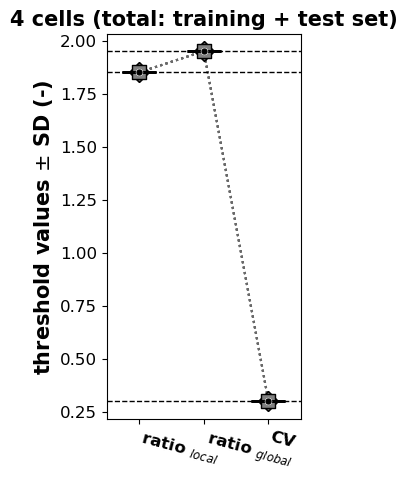

In [38]:
### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# style for markers    
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure
fig = plt.figure(1, (2.5,5))
ax = plt.subplot(1,1,1)
ax.set_title(str(N_cells_validated) + " cells (total: training + test set)", fontweight = 'bold', fontsize = size_labels)
ax.set_xticks([1,2,3])

ax.set_xlim((0.5, 3.5))
# if desired, set y-axis limits manually
#ax.set_ylim(())

ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
  
labels = ["ratio " + r'$_{local}$', "ratio "+r'$_{global}$', "CV"]
ax.set_xticklabels(labels, fontweight = 'bold', rotation = -15, ha = 'left')
ax.set_ylabel("threshold values " r'$\pm$ SD (-)', fontweight = 'bold', fontsize = size_labels)
        


local = []; overall = []; cv = []
for i1 in range(len(thresholds_outcomes)):
    outcome = thresholds_outcomes[i1]
    local.append(outcome[0]); overall.append(outcome[1]); cv.append(outcome[2])
    ax.scatter([1, 2, 3], outcome, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax.plot([1,2,3], outcome, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

# horizontal lines to visualise the obtained mean values for the 3 thresholds
ax.axhline(np.mean(cv), color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(np.mean(local), color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(np.mean(overall), color = 'black', linestyle = 'dashed', linewidth = 1)
    
    
thresholds_mean = [np.mean(local), np.mean(overall), np.mean(cv)]; thresholds_sd = [np.std(local), np.std(overall), np.std(cv)]
print(thresholds_mean)
ax.errorbar([1, 2, 3], thresholds_mean, fmt = 'none', yerr = thresholds_sd, ecolor = 'black', elinewidth = 1.5, capsize = 12.5, capthick = 2, zorder = 3)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'white', s = 75, zorder = 4)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'black', s = 50, zorder = 4)




**difference between manual punctum detection and PunctaFinder results.**

for _training set_

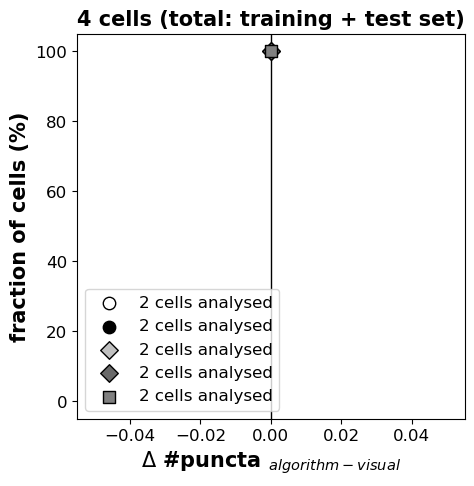

In [39]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells (total: training + test set)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_training_outcomes)):
    data_i2 = delta_training_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_training[i2]) + " cells analysed")
    
ax.legend(fontsize = size_ticks)


for _test set_

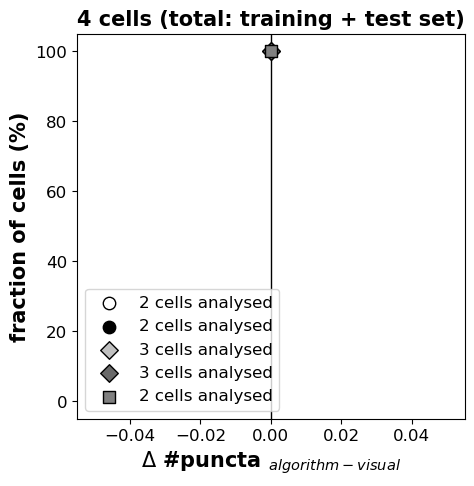

In [40]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells (total: training + test set)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_test_outcomes)):
    data_i2 = delta_test_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_test[i2]) + " cells analysed")
    
ax.legend(fontsize = size_ticks)


**FP and FN occurrence rates**
for _training_ set

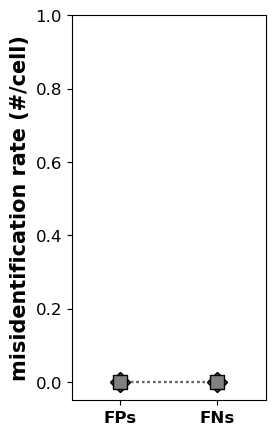

In [41]:
# FP and FN rates obtained from TRAINING DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    training = np.array(training_outcomes[i1]); training_corrected = (training/training[-1])[:-1] # divide by # cells to convert to rate
    combined = list(training_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    
    

for _test_ set

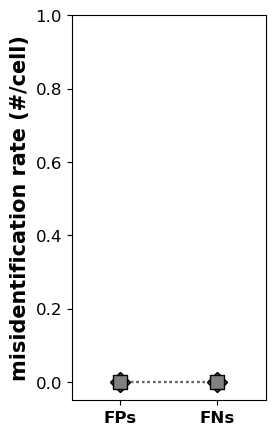

In [42]:
# FP and FN rates obtained from TEST DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    test = np.array(test_outcomes[i1]); test_corrected = (test/test[-1])[:-1] # divide by # cells to convert to rate
    combined = list(test_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    
    